In [132]:
import spacy

!spacy download en_core_web_sm
;

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 24.1 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


''

In [2]:
spacy.load('en_core_web_sm')

In [3]:
import os

from spacy import displacy

import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'

import plotly.express as px

In [4]:
texts = []
file_names = []

for _file_name in os.listdir('data'):
    if _file_name.endswith('.txt'):
        texts.append(open('data' + '/' + _file_name, 'r', encoding='utf-8').read())
        file_names.append(_file_name)

In [5]:
d = {'Filename':file_names,'Text':texts}

In [6]:
laufey_df = pd.DataFrame(d)

In [104]:
laufey_df.head(15)

,Filename,Text
0,Goddess,It always goes like this Could've predicted it...
1,I Wish You Love,I wish you bluebirds in the spring To give you...
2,Best friend,It's come to my attention That I don't show en...
3,LIke The Movies,"Maybe one day, I'll fall in a bookstore Into t..."
4,Bewitched,Wrapped me in your arms Leaned in and whispere...
5,Fragile,Will you let me come closer to you? I know tha...
6,From The Start,Don't you notice how I get quiet when there's ...
7,Falling Behind,Moved out to a new city June is dawning down o...
8,Promise,I made a promise To distance myself Took a fli...
9,Beautiful Stranger,"Beautiful stranger, sitting right there Looked..."


In [106]:
laufey_df['Text'] = laufey_df['Text'].str.replace('\s+', ' ', regex=True).str.strip()
laufey_df.head(15)

<>:1: SyntaxWarning:

invalid escape sequence '\s'

<>:1: SyntaxWarning:

invalid escape sequence '\s'

/var/folders/l8/r7pghqld70117g6hmhn2bx980000gn/T/ipykernel_38125/3420929192.py:1: SyntaxWarning:

invalid escape sequence '\s'



,Filename,Text
0,Goddess,It always goes like this Could've predicted it...
1,I Wish You Love,I wish you bluebirds in the spring To give you...
2,Best friend,It's come to my attention That I don't show en...
3,LIke The Movies,"Maybe one day, I'll fall in a bookstore Into t..."
4,Bewitched,Wrapped me in your arms Leaned in and whispere...
5,Fragile,Will you let me come closer to you? I know tha...
6,From The Start,Don't you notice how I get quiet when there's ...
7,Falling Behind,Moved out to a new city June is dawning down o...
8,Promise,I made a promise To distance myself Took a fli...
9,Beautiful Stranger,"Beautiful stranger, sitting right there Looked..."


In [9]:
laufey_df['Filename'] = laufey_df['Filename'].str.replace('.txt', '', regex=True)

In [108]:
laufey_df.head(15)

,Filename,Text
0,Goddess,It always goes like this Could've predicted it...
1,I Wish You Love,I wish you bluebirds in the spring To give you...
2,Best friend,It's come to my attention That I don't show en...
3,LIke The Movies,"Maybe one day, I'll fall in a bookstore Into t..."
4,Bewitched,Wrapped me in your arms Leaned in and whispere...
5,Fragile,Will you let me come closer to you? I know tha...
6,From The Start,Don't you notice how I get quiet when there's ...
7,Falling Behind,Moved out to a new city June is dawning down o...
8,Promise,I made a promise To distance myself Took a fli...
9,Beautiful Stranger,"Beautiful stranger, sitting right there Looked..."


In [110]:
metadata_df = pd.read_csv('laufeymetadata.csv')
metadata_df.head(15)

,ID,TITLE,ALBUM,RELEASE DATE,LYRICS
0,1,Beautiful Stranger,Everything I Know About Love,2022-08-16,"Beautiful stranger, sitting right there\nLooke..."
1,2,Best Friend,Typical of Me,2021-04-30,It's come to my attention\nThat I don't show e...
2,3,Bewitched,Bewitched,2023-09-08,Wrapped me in your arms\nLeaned in and whisper...
3,4,Bored,Bewitched: The Goddess Edition,2024-04-26,Why don't we\nCall it for what it is?\nCan't r...
4,5,Falling Behind,Everything I Know About Love,2022-08-26,Moved out to a new city\nJune is dawning down ...
5,6,Fragile,Everything I Know About Love,2022-08-26,Will you let me come closer to you?\nI know th...
6,7,From The Start,Bewitched,2023-09-08,Don't you notice how\nI get quiet when there's...
7,8,Goddess,Bewitched: The Goddess Edition,2024-04-26,It always goes like this\nCould've predicted i...
8,9,I Wish You Love,Typical of Me,2021-04-30,I wish you bluebirds in the spring\nTo give yo...
9,10,Like The Movies,Typical of Me,2021-04-30,"Maybe one day, I'll fall in a bookstore\nInto ..."


In [12]:
metadata_df.rename(columns={"TITLE": "Filename"}, inplace=True)

In [112]:
metadata_df.head(15)

,ID,TITLE,ALBUM,RELEASE DATE,LYRICS
0,1,Beautiful Stranger,Everything I Know About Love,2022-08-16,"Beautiful stranger, sitting right there\nLooke..."
1,2,Best Friend,Typical of Me,2021-04-30,It's come to my attention\nThat I don't show e...
2,3,Bewitched,Bewitched,2023-09-08,Wrapped me in your arms\nLeaned in and whisper...
3,4,Bored,Bewitched: The Goddess Edition,2024-04-26,Why don't we\nCall it for what it is?\nCan't r...
4,5,Falling Behind,Everything I Know About Love,2022-08-26,Moved out to a new city\nJune is dawning down ...
5,6,Fragile,Everything I Know About Love,2022-08-26,Will you let me come closer to you?\nI know th...
6,7,From The Start,Bewitched,2023-09-08,Don't you notice how\nI get quiet when there's...
7,8,Goddess,Bewitched: The Goddess Edition,2024-04-26,It always goes like this\nCould've predicted i...
8,9,I Wish You Love,Typical of Me,2021-04-30,I wish you bluebirds in the spring\nTo give yo...
9,10,Like The Movies,Typical of Me,2021-04-30,"Maybe one day, I'll fall in a bookstore\nInto ..."


In [14]:
laufey_meta_df = metadata_df.merge(laufey_df, on='Filename')

In [114]:
laufey_meta_df.head(15)

,ID,Filename,ALBUM,RELEASE DATE,LYRICS,Text,Doc,Tokens,Lemmas,POS,Proper_Nouns,Named_Entities,NE_Words
0,1,Beautiful Stranger,Everything I Know About Love,2022-08-16,"Beautiful stranger, sitting right there\nLooke...","Beautiful stranger, sitting right there Looked...","(Beautiful, stranger, ,, sitting, right, there...","[Beautiful, stranger, ,, sitting, right, there...","[beautiful, stranger, ,, sit, right, there, lo...","[(ADJ, JJ), (NOUN, NN), (PUNCT, ,), (VERB, VBG...","[Ladbroke, Grove]","[PERSON, ORDINAL, FAC, TIME]","[(Looked), (second), (Ladbroke, Grove), (the, ..."
1,3,Bewitched,Bewitched,2023-09-08,Wrapped me in your arms\nLeaned in and whisper...,Wrapped me in your arms Leaned in and whispere...,"(Wrapped, me, in, your, arms, Leaned, in, and,...","[Wrapped, me, in, your, arms, Leaned, in, and,...","[wrap, I, in, your, arm, lean, in, and, whispe...","[(VERB, VBD), (PRON, PRP), (ADP, IN), (PRON, P...","[London, Bewitched, London, Bewitched]","[ORDINAL, GPE, ORDINAL, WORK_OF_ART, ORDINAL, ...","[(first), (London), (second), (Cursing, at, th..."
2,4,Bored,Bewitched: The Goddess Edition,2024-04-26,Why don't we\nCall it for what it is?\nCan't r...,Why don't we Call it for what it is? Can't rem...,"(Why, do, n't, we, Call, it, for, what, it, is...","[Why, do, n't, we, Call, it, for, what, it, is...","[why, do, not, we, call, it, for, what, it, be...","[(SCONJ, WRB), (AUX, VBP), (PART, RB), (PRON, ...","[Bored, Bored, Baby, Bored, Charming, Baby, Baby]","[PRODUCT, ORDINAL, TIME, PRODUCT, PRODUCT]","[(Baby), (first), (morning), (Baby), (Baby)]"
3,5,Falling Behind,Everything I Know About Love,2022-08-26,Moved out to a new city\nJune is dawning down ...,Moved out to a new city June is dawning down o...,"(Moved, out, to, a, new, city, June, is, dawni...","[Moved, out, to, a, new, city, June, is, dawni...","[move, out, to, a, new, city, June, be, dawn, ...","[(VERB, VBN), (ADP, RP), (ADP, IN), (DET, DT),...","[June, Lovers, Ooh, Bossa, Hope]","[DATE, ORG, PERSON, PERSON, CARDINAL, CARDINAL...","[(June), (Lovers), (Ooh), (Stepped), (One), (t..."
4,6,Fragile,Everything I Know About Love,2022-08-26,Will you let me come closer to you?\nI know th...,Will you let me come closer to you? I know tha...,"(Will, you, let, me, come, closer, to, you, ?,...","[Will, you, let, me, come, closer, to, you, ?,...","[will, you, let, I, come, close, to, you, ?, I...","[(AUX, MD), (PRON, PRP), (VERB, VB), (PRON, PR...","[Nerve, Ooh, ooh, ooh, ooh, New]","[TIME, PERSON, DATE, DATE, TIME, PRODUCT, ORG]","[(the, morning), (Nerve), (a, year), (40, days..."
5,7,From The Start,Bewitched,2023-09-08,Don't you notice how\nI get quiet when there's...,Don't you notice how I get quiet when there's ...,"(Do, n't, you, notice, how, I, get, quiet, whe...","[Do, n't, you, notice, how, I, get, quiet, whe...","[do, not, you, notice, how, I, get, quiet, whe...","[(AUX, VBP), (PART, RB), (PRON, PRP), (VERB, V...","[blah, blah, Cupid, Confess, Unrequited, Love,...","[DATE, ORG, ORG, WORK_OF_ART, DATE, ORG]","[(one, day), (Cupid), (Unrequited), (Love), (t..."
6,8,Goddess,Bewitched: The Goddess Edition,2024-04-26,It always goes like this\nCould've predicted i...,It always goes like this Could've predicted it...,"(It, always, goes, like, this, Could, 've, pre...","[It, always, goes, like, this, Could, 've, pre...","[it, always, go, like, this, could, 've, predi...","[(PRON, PRP), (ADV, RB), (VERB, VBZ), (ADP, IN...","[Kissed, Reduced, Woke, Aphrodite, Reduced]",[PERSON],[(Kissed)]
7,9,I Wish You Love,Typical of Me,2021-04-30,I wish you bluebirds in the spring\nTo give yo...,I wish you bluebirds in the spring To give you...,"(I, wish, you, bluebirds, in, the, spring, To,...","[I, wish, you, bluebirds, in, the, spring, To,...","[I, wish, you, bluebird, in, the, spring, to, ...","[(PRON, PRP), (VERB, VBP), (PRON, PRP), (NOUN,...","[July, Love]","[DATE, DATE, WORK_OF_ART]","[(the, spring), (July), (Love)]"
8,12,Magnolia,Typical of Me,2021-04-30,"Magnolia, she could have anyone 

In [16]:
nlp = spacy.load('en_core_web_sm')

print(nlp.pipe_names)

['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [17]:
sentence = "This is 'an' example? sentence"

doc = nlp(sentence)

In [18]:
for token in doc:
    print(token.text, token.pos_)

This PRON
is AUX
' PUNCT
an DET
' PUNCT
example NOUN
? PUNCT
sentence NOUN


In [19]:
def process_text(text):
    return nlp(text)

In [20]:
laufey_meta_df['Doc'] = laufey_meta_df['Text'].apply(process_text)

In [21]:
def get_token(doc):
    return [(token.text) for token in doc]

In [128]:
laufey_meta_df['Tokens'] = laufey_meta_df['Doc'].apply(get_token)
laufey_meta_df.head()

,ID,Filename,ALBUM,RELEASE DATE,LYRICS,Text,Doc,Tokens,Lemmas,POS,Proper_Nouns,Named_Entities,NE_Words
0,1,Beautiful Stranger,Everything I Know About Love,2022-08-16,"Beautiful stranger, sitting right there\nLooke...","Beautiful stranger, sitting right there Looked...","(Beautiful, stranger, ,, sitting, right, there...","[Beautiful, stranger, ,, sitting, right, there...","[beautiful, stranger, ,, sit, right, there, lo...","[(ADJ, JJ), (NOUN, NN), (PUNCT, ,), (VERB, VBG...","[Ladbroke, Grove]","[PERSON, ORDINAL, FAC, TIME]","[(Looked), (second), (Ladbroke, Grove), (the, ..."
1,3,Bewitched,Bewitched,2023-09-08,Wrapped me in your arms\nLeaned in and whisper...,Wrapped me in your arms Leaned in and whispere...,"(Wrapped, me, in, your, arms, Leaned, in, and,...","[Wrapped, me, in, your, arms, Leaned, in, and,...","[wrap, I, in, your, arm, lean, in, and, whispe...","[(VERB, VBD), (PRON, PRP), (ADP, IN), (PRON, P...","[London, Bewitched, London, Bewitched]","[ORDINAL, GPE, ORDINAL, WORK_OF_ART, ORDINAL, ...","[(first), (London), (second), (Cursing, at, th..."
2,4,Bored,Bewitched: The Goddess Edition,2024-04-26,Why don't we\nCall it for what it is?\nCan't r...,Why don't we Call it for what it is? Can't rem...,"(Why, do, n't, we, Call, it, for, what, it, is...","[Why, do, n't, we, Call, it, for, what, it, is...","[why, do, not, we, call, it, for, what, it, be...","[(SCONJ, WRB), (AUX, VBP), (PART, RB), (PRON, ...","[Bored, Bored, Baby, Bored, Charming, Baby, Baby]","[PRODUCT, ORDINAL, TIME, PRODUCT, PRODUCT]","[(Baby), (first), (morning), (Baby), (Baby)]"
3,5,Falling Behind,Everything I Know About Love,2022-08-26,Moved out to a new city\nJune is dawning down ...,Moved out to a new city June is dawning down o...,"(Moved, out, to, a, new, city, June, is, dawni...","[Moved, out, to, a, new, city, June, is, dawni...","[move, out, to, a, new, city, June, be, dawn, ...","[(VERB, VBN), (ADP, RP), (ADP, IN), (DET, DT),...","[June, Lovers, Ooh, Bossa, Hope]","[DATE, ORG, PERSON, PERSON, CARDINAL, CARDINAL...","[(June), (Lovers), (Ooh), (Stepped), (One), (t..."
4,6,Fragile,Everything I Know About Love,2022-08-26,Will you let me come closer to you?\nI know th...,Will you let me come closer to you? I know tha...,"(Will, you, let, me, come, closer, to, you, ?,...","[Will, you, let, me, come, closer, to, you, ?,...","[will, you, let, I, come, close, to, you, ?, I...","[(AUX, MD), (PRON, PRP), (VERB, VB), (PRON, PR...","[Nerve, Ooh, ooh, ooh, ooh, New]","[TIME, PERSON, DATE, DATE, TIME, PRODUCT, ORG]","[(the, morning), (Nerve), (a, year), (40, days..."


In [130]:
tokens = laufey_meta_df[['Text', 'Tokens']].copy()
tokens.head()

,Text,Tokens
0,"Beautiful stranger, sitting right there Looked...","[Beautiful, stranger, ,, sitting, right, there..."
1,Wrapped me in your arms Leaned in and whispere...,"[Wrapped, me, in, your, arms, Leaned, in, and,..."
2,Why don't we Call it for what it is? Can't rem...,"[Why, do, n't, we, Call, it, for, what, it, is..."
3,Moved out to a new city June is dawning down o...,"[Moved, out, to, a, new, city, June, is, dawni..."
4,Will you let me come closer to you? I know tha...,"[Will, you, let, me, come, closer, to, you, ?,..."


In [24]:
def get_lemma(doc):
    return [(token.lemma_) for token in doc]
laufey_meta_df['Lemmas'] = laufey_meta_df['Doc'].apply(get_lemma)

In [25]:
print(f'"Love" appears in the text tokens column ' + str(laufey_meta_df['Tokens'].apply(lambda x: x.count('write')).sum()) + ' times.')
print(f'"Love" appears in the lemmas column ' + str(laufey_meta_df['Lemmas'].apply(lambda x: x.count('write')).sum()) + ' times.')

"Love" appears in the text tokens column 0 times.
"Love" appears in the lemmas column 2 times.


In [26]:
def get_pos(doc):
    return [(token.pos_, token.tag_) for token in doc]
    
laufey_meta_df['POS'] = laufey_meta_df['Doc'].apply(get_pos)

In [80]:
list(laufey_meta_df['POS']) ;

In [28]:
def extract_proper_nouns(doc):
    return [token.text for token in doc if token.pos_ == 'PROPN']
laufey_meta_df['Proper_Nouns'] = laufey_meta_df['Doc'].apply(extract_proper_nouns)

In [29]:
list(laufey_meta_df['Proper_Nouns'])

[['Ladbroke', 'Grove'],
 ['London', 'Bewitched', 'London', 'Bewitched'],
 ['Bored', 'Bored', 'Baby', 'Bored', 'Charming', 'Baby', 'Baby'],
 ['June', 'Lovers', 'Ooh', 'Bossa', 'Hope'],
 ['Nerve', 'Ooh', 'ooh', 'ooh', 'ooh', 'New'],
 ['blah',
  'blah',
  'Cupid',
  'Confess',
  'Unrequited',
  'Love',
  'Cupid',
  'Confess',
  'Confess'],
 ['Kissed', 'Reduced', 'Woke', 'Aphrodite', 'Reduced'],
 ['July', 'Love'],
 ['Magnolia',
  'Magnolia',
  'Beautiful',
  'Magnolia',
  'Magnolia',
  'Ooh',
  'Oh',
  'Magnolia',
  'Magnolia',
  'Enchants',
  'Perfection',
  'Magnolia',
  'Magnolia',
  'Magnolia'],
 ['Melrose', 'Avenue'],
 ['Valentine', 'Valentine']]

In [30]:
def extract_named_entities(doc):
    return [ent.label_ for ent in doc.ents]

laufey_meta_df['Named_Entities'] = laufey_meta_df['Doc'].apply(extract_named_entities)
laufey_meta_df['Named_Entities']

0                          [PERSON, ORDINAL, FAC, TIME]
1     [ORDINAL, GPE, ORDINAL, WORK_OF_ART, ORDINAL, ...
2            [PRODUCT, ORDINAL, TIME, PRODUCT, PRODUCT]
3     [DATE, ORG, PERSON, PERSON, CARDINAL, CARDINAL...
4        [TIME, PERSON, DATE, DATE, TIME, PRODUCT, ORG]
5              [DATE, ORG, ORG, WORK_OF_ART, DATE, ORG]
6                                              [PERSON]
7                             [DATE, DATE, WORK_OF_ART]
8                [GPE, LOC, GPE, PERSON, GPE, GPE, LOC]
9                             [DATE, TIME, WORK_OF_ART]
10      [DATE, PERSON, CARDINAL, ORDINAL, TIME, PERSON]
Name: Named_Entities, dtype: object

In [31]:
def extract_named_entities(doc):
    return [ent for ent in doc.ents]

laufey_meta_df['NE_Words'] = laufey_meta_df['Doc'].apply(extract_named_entities)
laufey_meta_df['NE_Words']

0     [(Looked), (second), (Ladbroke, Grove), (the, ...
1     [(first), (London), (second), (Cursing, at, th...
2          [(Baby), (first), (morning), (Baby), (Baby)]
3     [(June), (Lovers), (Ooh), (Stepped), (One), (t...
4     [(the, morning), (Nerve), (a, year), (40, days...
5     [(one, day), (Cupid), (Unrequited), (Love), (t...
6                                            [(Kissed)]
7                       [(the, spring), (July), (Love)]
8     [(Magnolia), (Magnolia), (Magnolia), (Will), (...
9     [(sixteen, long, days), (last, night), (Melros...
10    [(years), (Valentine), (only, 21), (first), (s...
Name: NE_Words, dtype: object

In [126]:
doc = laufey_meta_df['Doc'][10]

displacy.render(doc, style='ent', jupyter=True)

In [33]:
laufey_meta_df.to_csv('laufey_lyrics_with_spaCy_tags.csv')

In [34]:
pos_analysis_df = laufey_meta_df[['Filename','LYRICS', 'Doc']]

num_list = []

def get_pos_tags(doc):
    dictionary = {}
    num_pos = doc.count_by(spacy.attrs.POS)
    for k,v in sorted(num_pos.items()):
        dictionary[doc.vocab[k].text] = v
    num_list.append(dictionary)

pos_analysis_df.loc['C_POS'] = pos_analysis_df['Doc'].apply(get_pos_tags)

In [35]:
pos_counts = pd.DataFrame(num_list)
columns = list(pos_counts.columns)

idx = 0
new_col = pos_analysis_df['LYRICS']
pos_counts.insert(loc=idx, column='LYRICS', value=new_col)

pos_counts

,LYRICS,ADJ,ADP,ADV,AUX,CCONJ,DET,NOUN,PART,PRON,PROPN,PUNCT,SCONJ,VERB,INTJ,NUM
0,"Beautiful stranger, sitting right there\nLooke...",15,13,16,18,6,16,37,8,34,2,10,6,40,NaN,NaN
1,Wrapped me in your arms\nLeaned in and whisper...,13,19,19,15,8,20,26,4,59,4,12,2,46,NaN,NaN
2,Why don't we\nCall it for what it is?\nCan't r...,26,19,21,34,13,12,28,14,50,7,43,6,41,4.0,NaN
3,Moved out to a new city\nJune is dawning down ...,12,20,7,17,7,13,29,11,27,5,7,3,26,1.0,3.0
4,Will you let me come closer to you?\nI know th...,13,17,15,23,6,13,33,5,44,6,28,6,33,11.0,1.0
5,Don't you notice how\nI get quiet when there's...,8,21,11,13,8,15,22,8,45,9,21,8,39,5.0,1.0
6,It always goes like this\nCould've predicted i...,7,19,16,19,4,9,22,8,51,5,3,9,31,4.0,1.0
7,I wish you bluebirds in the spring\nTo give yo...,15,12,7,4,11,9,21,5,42,2,12,5,32,NaN,NaN
8,"Magnolia, she could have anyone in the world\n...",5,19,5,19,3,10,23,4,32,14,7,5,23,NaN,NaN
9,I made a promise\nTo distance myself\nTook a f...,7,14,13,24,2,7,15,16,44,2,6,4,24,1.0,1.0


In [36]:
average_pos_df = pos_counts.groupby(['LYRICS']).mean()

average_pos_df = average_pos_df.round(0)

average_pos_df = average_pos_df.reset_index()

average_pos_df

,LYRICS,ADJ,ADP,ADV,AUX,CCONJ,DET,NOUN,PART,PRON,PROPN,PUNCT,SCONJ,VERB,INTJ,NUM
0,"Beautiful stranger, sitting right there\nLooke...",15.0,13.0,16.0,18.0,6.0,16.0,37.0,8.0,34.0,2.0,10.0,6.0,40.0,NaN,NaN
1,Don't you notice how\nI get quiet when there's...,8.0,21.0,11.0,13.0,8.0,15.0,22.0,8.0,45.0,9.0,21.0,8.0,39.0,5.0,1.0
2,I made a promise\nTo distance myself\nTook a f...,7.0,14.0,13.0,24.0,2.0,7.0,15.0,16.0,44.0,2.0,6.0,4.0,24.0,1.0,1.0
3,I wish you bluebirds in the spring\nTo give yo...,15.0,12.0,7.0,4.0,11.0,9.0,21.0,5.0,42.0,2.0,12.0,5.0,32.0,NaN,NaN
4,I've rejected affection\nFor years and years\n...,7.0,11.0,19.0,22.0,5.0,16.0,24.0,9.0,50.0,2.0,15.0,8.0,36.0,1.0,3.0
5,It always goes like this\nCould've predicted i...,7.0,19.0,16.0,19.0,4.0,9.0,22.0,8.0,51.0,5.0,3.0,9.0,31.0,4.0,1.0
6,"Magnolia, she could have anyone in the world\n...",5.0,19.0,5.0,19.0,3.0,10.0,23.0,4.0,32.0,14.0,7.0,5.0,23.0,NaN,NaN
7,Moved out to a new city\nJune is dawning down ...,12.0,20.0,7.0,17.0,7.0,13.0,29.0,11.0,27.0,5.0,7.0,3.0,26.0,1.0,3.0
8,Why don't we\nCall it for what it is?\nCan't r...,26.0,19.0,21.0,34.0,13.0,12.0,28.0,14.0,50.0,7.0,43.0,6.0,41.0,4.0,NaN
9,Will you let me come closer to you?\nI know th...,13.0,17.0,15.0,23.0,6.0,13.0,33.0,5.0,44.0,6.0,28.0,6.0,33.0,11.0,1.0


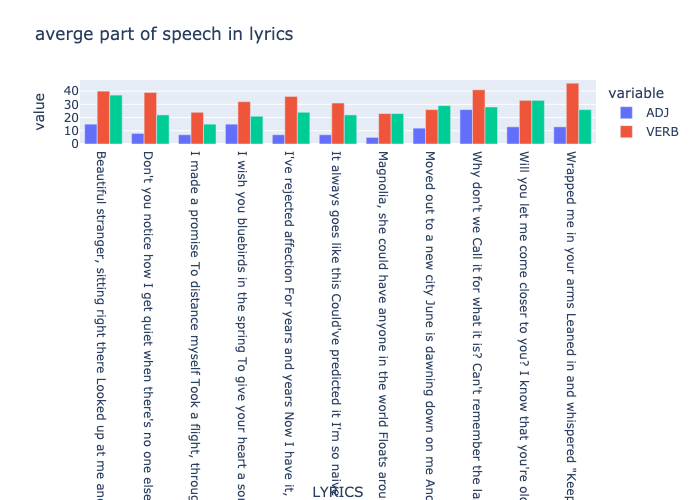

In [100]:
fig = px.bar(average_pos_df, x="LYRICS", y=["ADJ", "VERB", "NOUN"], title="averge part of speech in lyrics", barmode='group')
fig.show("png")

In [38]:
laufey_meta_df.to_csv('laufey_lyrics_with_spaCy_tags.csv')